# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"

hotels = pd.read_csv(url)

hotels.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1.The main stakeholders are hotel managers, marketing teams, and revenue managers.

2.Hotel managers want to reduce cancellations, marketing teams want to understand customer behavior, and revenue managers want to improve occupancy and revenue.

3.The business problem I want to investigate is which booking characteristics are associated with cancellations and how hotels can use this information to improve their booking strategies.




## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [2]:

# Dataset summary
hotels.info()

# Summary statistics
display(hotels.describe())

# Missing values
print("MISSING VALUES:")
print(hotels.isnull().sum())

# Duplicate rows
print("DUPLICATE ROWS:")
print(hotels.duplicated().sum())

# Check for unusual numerical values
print("UNUSUAL VALUES:")
print("Negative ADR:", (hotels["adr"] < 0).sum())
print("Zero guests:", (
    (hotels["adults"] == 0) &
    (hotels["children"].fillna(0) == 0) &
    (hotels["babies"] == 0)
).sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


MISSING VALUES:
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340


### Reflection:
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue?

### ✍️ Your Response: 🔧
1.The dataset contains 119,390 bookings and 32 columns. I found several data-quality issues, including 488 missing country values, 16,340 missing agent values, and 112,593 missing company values. There are also 31,994 duplicate rows, one negative daily rate of -6.38, and 180 bookings with zero guests.

2.I would fill missing country information with "Unknown" and investigate missing agent and company values, since some bookings may not involve either. I would also review the duplicate rows before deleting them because separate reservations could have identical information. Finally, I would investigate the negative daily rate and bookings with zero guests to determine whether they are data-entry errors.



## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

Cancellation percentages:
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


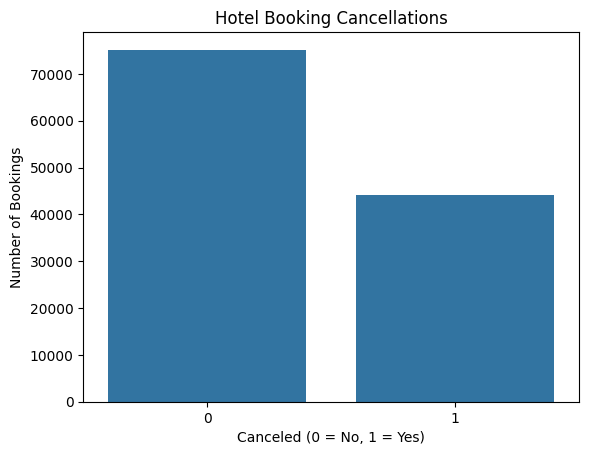

Lead time summary:
count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64


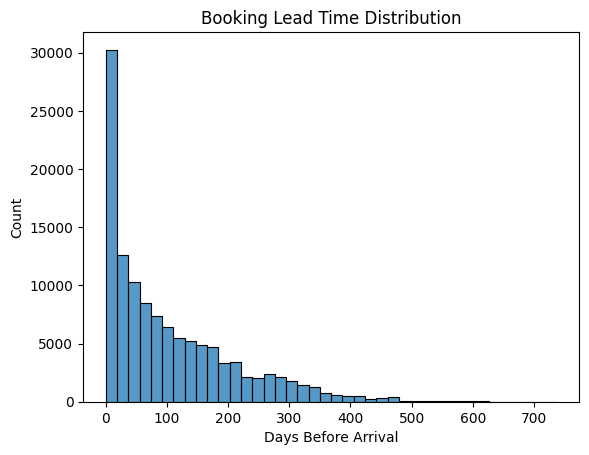

Bookings by hotel type:
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64


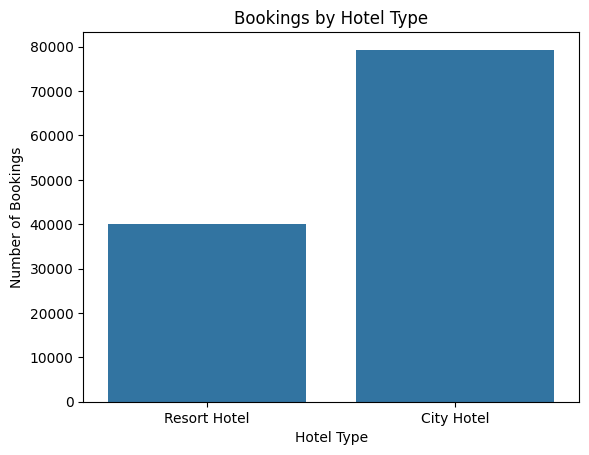

In [3]:

# Variable 1: Booking cancellations
print("Cancellation percentages:")
print(
    hotels["is_canceled"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sns.countplot(data=hotels, x="is_canceled")
plt.title("Hotel Booking Cancellations")
plt.xlabel("Canceled (0 = No, 1 = Yes)")
plt.ylabel("Number of Bookings")
plt.show()

# Variable 2: Lead time
print("Lead time summary:")
print(hotels["lead_time"].describe())

sns.histplot(data=hotels, x="lead_time", bins=40)
plt.title("Booking Lead Time Distribution")
plt.xlabel("Days Before Arrival")
plt.show()

# Variable 3: Hotel type
print("Bookings by hotel type:")
print(hotels["hotel"].value_counts())

sns.countplot(data=hotels, x="hotel")
plt.title("Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.show()



### Reflection:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – I explored booking cancellations and found that 37.04% of reservations were canceled, while 62.96% were not. This shows that cancellations affect a significant portion of hotel bookings and are an important issue for hotel managers.
- I examined how far in advance customers book their rooms. The average lead time was 104 days, while the median was 69 days. Some bookings were made as far as 737 days in advance. This suggests that booking behavior varies considerably between customers.
- I compared the number of bookings for city and resort hotels. City hotels received 79,330 bookings, compared with 40,060 for resort hotels. City hotels account for approximately two-thirds of all reservations in the dataset.


## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

Cancellation rates by hotel type:


,count,mean,cancellation_pct
hotel,,,
City Hotel,79330,0.42,41.73
Resort Hotel,40060,0.28,27.76


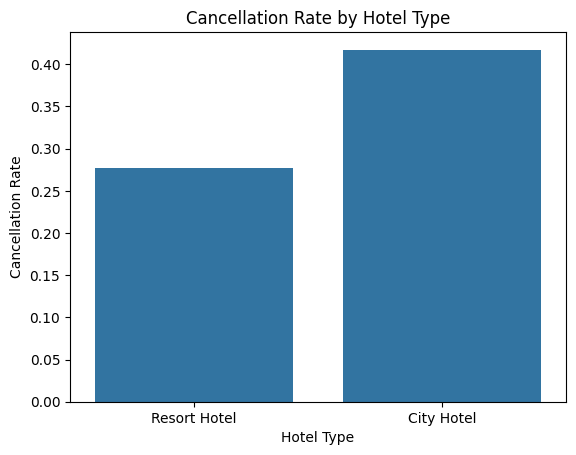

Cancellation rates by lead time:


,count,mean,cancellation_pct
lead_time_group,,,
0-30,38706,0.19,18.56
31-90,29553,0.38,37.70
91-180,26439,0.45,44.71
181+,24692,0.57,57.01


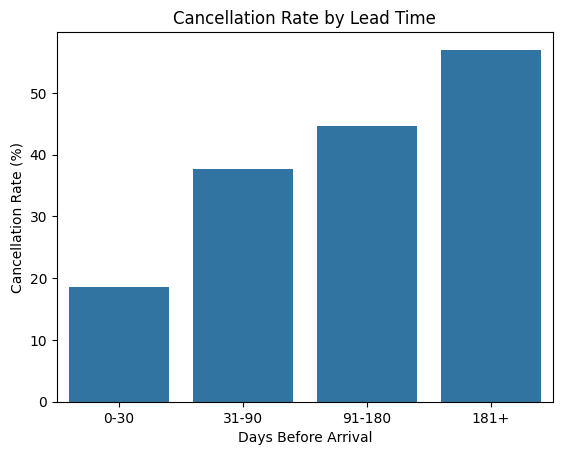

In [4]:

# Relationship 1: Hotel type vs. cancellation rate

hotel_cancel = (
    hotels.groupby("hotel")["is_canceled"]
    .agg(["count", "mean"])
)

hotel_cancel["cancellation_pct"] = (
    hotel_cancel["mean"] * 100
)

print("Cancellation rates by hotel type:")
display(hotel_cancel.round(2))

sns.barplot(
    data=hotels,
    x="hotel",
    y="is_canceled",
    errorbar=None
)
plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate")
plt.show()


# Relationship 2: Lead time vs. cancellations

hotels["lead_time_group"] = pd.cut(
    hotels["lead_time"],
    bins=[-1, 30, 90, 180, float("inf")],
    labels=["0-30", "31-90", "91-180", "181+"]
)

lead_cancel = (
    hotels.groupby("lead_time_group", observed=True)
    ["is_canceled"]
    .agg(["count", "mean"])
)

lead_cancel["cancellation_pct"] = (
    lead_cancel["mean"] * 100
)

print("Cancellation rates by lead time:")
display(lead_cancel.round(2))

sns.barplot(
    x=lead_cancel.index,
    y=lead_cancel["cancellation_pct"]
)
plt.title("Cancellation Rate by Lead Time")
plt.xlabel("Days Before Arrival")
plt.ylabel("Cancellation Rate (%)")
plt.show()



### Reflection:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1: Hotel type and cancellation rate
I compared cancellation rates between city and resort hotels. City hotels had a cancellation rate of 41.73%, compared with 27.76% for resort hotels. This suggests that city hotels experience more cancellations and may benefit from strategies aimed at reducing them.

- **Relationship 2: Lead time and cancellation rate
I compared booking lead time with cancellation rates. Reservations made 0-30 days in advance had an 18.56% cancellation rate, while reservations made more than 180 days in advance had a 57.01% cancellation rate. Cancellation rates increased across each lead-time group, suggesting that customers who book further in advance are more likely to cancel.


## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection:
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧
1. My selected insight was that customers who book further in advance have higher cancellation rates. Bookings made over 180 days in advance had a 57.01% cancellation rate, compared to 18.56% for bookings made within 30 days.
2. This involves variability because cancellation rates change depending on how far in advance customers book.
3. Predictive analytics would help hotels estimate which reservations are more likely to be canceled based on lead time and other booking characteristics. This could help managers anticipate occupancy and make better business decisions.



## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection:
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. The biggest trends were that city hotels had a 41.73% cancellation rate compared to 27.76% for resort hotels. Cancellations also increased with lead time, reaching 57.01% for bookings made more than 180 days in advance.

2. These findings help hotel managers identify which bookings are more likely to be canceled. Understanding these patterns can help them improve occupancy planning and reduce potential revenue losses.

3. I recommend sending additional reservation reminders to customers who book far in advance. City hotels should also investigate their higher cancellation rates and consider strategies to reduce them.

4. This relates to my customized learning outcome by helping me develop my Python and business analytics skills. I used real data to identify patterns, create visualizations, and make business recommendations. These skills will help me make data-driven decisions in marketing and other business roles.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [ ]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"